# Analista de Marketing i Estratégia Comercial: 29/06/2026
Cuál es el precio medio de los alojamientos por tipo de alojamiento en cada ciudad?

In [32]:
# cambiar por el dataset listo

import mysql.connector
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.stats.multicomp import pairwise_tukeyhsd

In [20]:
# cambiar por el dataset listo

conexion = mysql.connector.connect(
    host="212.227.148.202",
    port=3306,
    user="Equipo34",
    password="E1q2u3i4p5o34",
    database="Equip_34"
)



df = pd.read_sql(
    "SELECT * FROM Tourist_Accommodation;",
    conexion
)


/var/folders/9_/3pn1l9cn1674q1mxwt092dy00000gn/T/ipykernel_85965/2282883202.py:13: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(


### Desglose y preparación de la pregunta-resupuesta
Variables 
- price avg 
- room_type
- city 

Métricas (cálculo) 
- AVG agrupado por tipo y ciudad 

Análisis (tipo de herramienta o elemento estadístico) 
- MEDIA (ir haciendo zoom --> global --> ciudad --> tipo --> tipo y ciudad) 
- Test de diferencia de medias (comparativa puede ser anova o tuckey p ejemplo) 

Respuesta
- El precio medio por tipo de alojamiento y ciudad es X€. 
- Comparar y realizar una frase en diferencias de interés  

In [21]:
df.groupby(['room_type', 'city'])['price'].mean().sort_values(ascending=False)

room_type        city     
Entire home/apt  mallorca     1713.198381
                 menorca      1647.301587
Hotel room       barcelona    1444.285714
                 mallorca     1401.666667
Entire home/apt  barcelona    1295.792181
                 girona       1229.496198
                 sevilla      1046.236559
Hotel room       valencia      955.000000
Entire home/apt  madrid        938.574514
Hotel room       sevilla       918.571429
                 madrid        902.500000
Entire home/apt  malaga        817.333333
                 valencia      794.476190
Private room     mallorca      709.756098
Hotel room       malaga        703.333333
                 girona        625.000000
Private room     girona        602.115385
                 sevilla       599.027778
                 menorca       574.545455
Shared room      mallorca      493.333333
Private room     barcelona     455.277021
Shared room      barcelona     373.333333
Private room     madrid        370.875764
       

Precio promedio global

In [22]:
precio_medio_global=df['price'].mean().round(2)
print(precio_medio_global)

1011.1


Precio por ciudad

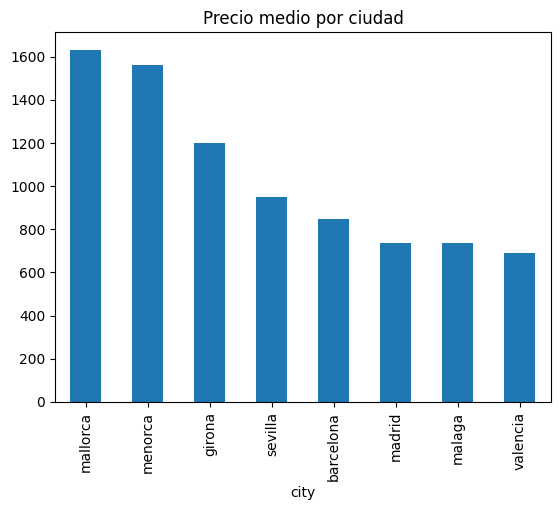

In [23]:
df.groupby('city')['price'].mean().sort_values(ascending=False).plot(kind='bar', title='Precio medio por ciudad') ; 

ANOVA entre ciudades

In [33]:
print("=== COMPARATIVA GLOBAL DE PRECIOS ENTRE CIUDADES ===")

# Pasamos los datos filtrando los nulos solo al momento de ejecutar el test
tukey_ciudades = pairwise_tukeyhsd(
    endog=df['price'].dropna(), 
    groups=df.loc[df['price'].notna(), 'city'], 
    alpha=0.05
)

# Convertimos a DataFrame de pandas para leerlo fácilmente
df_ciudades = pd.DataFrame(data=tukey_ciudades._results_table.data[1:], 
                           columns=tukey_ciudades._results_table.data[0])

# Mostramos las comparaciones donde SÍ hay diferencias significativas (reject == True)
print("\n--- Comparaciones entre ciudades que resultaron SIGNIFICATIVAS ---")
print(df_ciudades[df_ciudades['reject'] == True].to_string(index=False))

=== COMPARATIVA GLOBAL DE PRECIOS ENTRE CIUDADES ===

--- Comparaciones entre ciudades que resultaron SIGNIFICATIVAS ---
   group1   group2  meandiff  p-adj      lower     upper  reject
barcelona   girona  350.5869 0.0000   262.5314  438.6425    True
barcelona   madrid -109.4489 0.0012  -190.6573  -28.2405    True
barcelona mallorca  784.5334 0.0000   695.7068  873.3599    True
barcelona  menorca  713.8848 0.0000   504.7995  922.9700    True
barcelona valencia -158.9805 0.0209  -304.4911  -13.4699    True
   girona   madrid -460.0358 0.0000  -554.8468 -365.2247    True
   girona   malaga -463.0849 0.0000  -608.6291 -317.5408    True
   girona mallorca  433.9465 0.0000   332.5340  535.3589    True
   girona  menorca  363.2978 0.0000   148.5632  578.0325    True
   girona  sevilla -246.3937 0.0000  -390.3881 -102.3993    True
   girona valencia -509.5674 0.0000  -663.0850 -356.0498    True
   madrid mallorca  893.9822 0.0000   798.4547  989.5098    True
   madrid  menorca  823.3336 0.000

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/scipy/integrate/_quadpack_py.py:1286: IntegrationWarning: The integral is probably divergent, or slowly convergent.
  quad_r = quad(f, low, high, args=args, full_output=self.full_output,


Precio por tipo de alojamiento

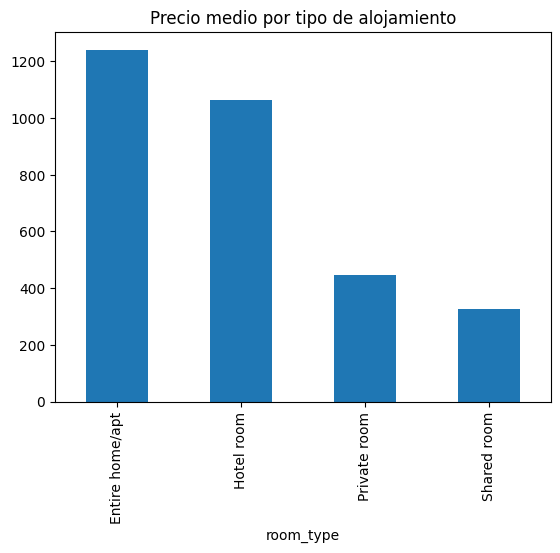

In [24]:
df.groupby('room_type')['price'].mean().sort_values(ascending=False).plot(kind='bar', title='Precio medio por tipo de alojamiento') ;

ANOVA entre tipo de alojamiento

In [34]:
print("\n=== COMPARATIVA GLOBAL DE PRECIOS ENTRE TIPOS DE ALOJAMIENTO ===")

# Pasamos los datos filtrando los nulos solo al momento de ejecutar el test
tukey_tipos = pairwise_tukeyhsd(
    endog=df['price'].dropna(), 
    groups=df.loc[df['price'].notna(), 'room_type'], 
    alpha=0.05
)

# Convertimos a DataFrame de pandas
df_tipos = pd.DataFrame(data=tukey_tipos._results_table.data[1:], 
                        columns=tukey_tipos._results_table.data[0])

# Mostramos el resultado completo (al ser solo 4 tipos, la tabla es pequeña y fácil de leer)
print("\n--- Resultado de todas las comparaciones de alojamiento ---")
print(df_tipos.to_string(index=False))


=== COMPARATIVA GLOBAL DE PRECIOS ENTRE TIPOS DE ALOJAMIENTO ===

--- Resultado de todas las comparaciones de alojamiento ---
         group1       group2  meandiff  p-adj      lower     upper  reject
Entire home/apt   Hotel room -178.0942 0.5426  -521.7320  165.5436   False
Entire home/apt Private room -793.3312 0.0000  -846.2168 -740.4457    True
Entire home/apt  Shared room -914.1478 0.0000 -1215.4950 -612.8006    True
     Hotel room Private room -615.2370 0.0000  -960.6219 -269.8522    True
     Hotel room  Shared room -736.0536 0.0002 -1191.3600 -280.7471    True
   Private room  Shared room -120.8165 0.7357  -424.1544  182.5213   False


Crear la tabla agrupada (MultiIndex)

In [25]:

tabla_opcion1 = (
    df.groupby(["city", "room_type"])["price"]
    .mean()
    .sort_values(ascending=False)
)


 2. Graficar agrupando visualmente por el primer nivel (city)
.unstack() pasa 'room_type' a las columnas, creando el agrupamiento ideal para el gráfico

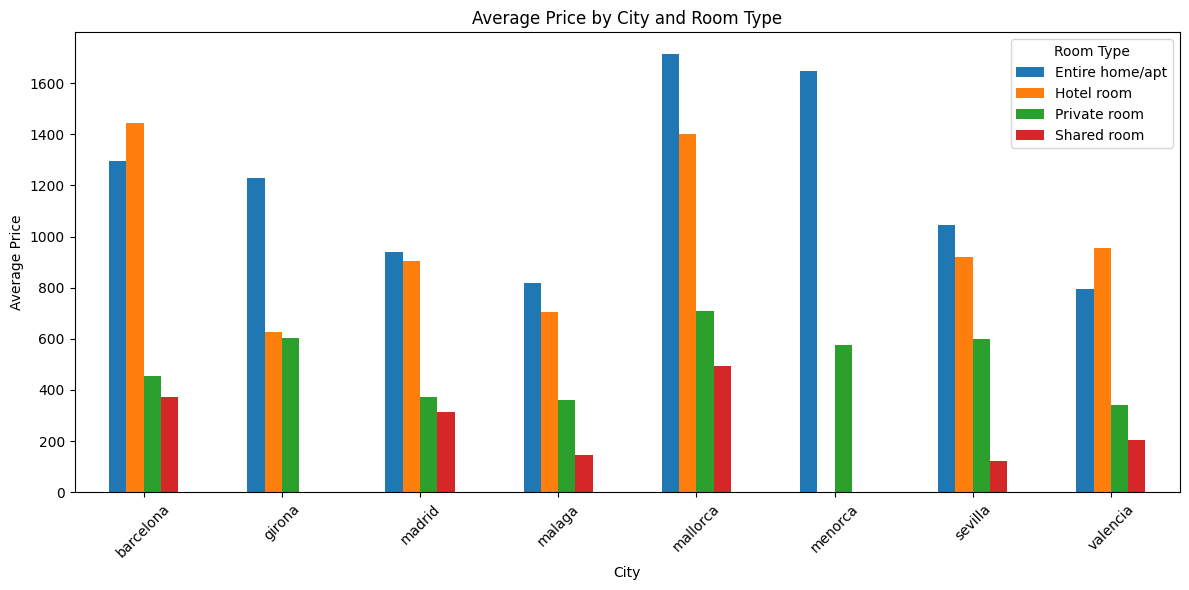

In [26]:
tabla_opcion1.unstack().plot(kind="bar", figsize=(12, 6))

plt.title("Average Price by City and Room Type")
plt.xlabel("City")
plt.ylabel("Average Price")
plt.xticks(rotation=45)
plt.legend(title="Room Type")
plt.tight_layout()
plt.show()

POST- HOC Comparativa de alojamientos entre tipos en la misma ciudad

In [30]:
import pandas as pd
from statsmodels.stats.multicomp import pairwise_tukeyhsd

print("=== PARTE 1: ALOJAMIENTOS DENTRO DE LA MISMA CIUDAD ===")

# Recorremos cada ciudad con pandas
for ciudad, sub_df in df.groupby('city'):
    print(f"\n--- Resultados para: {ciudad} ---")
    
    # Hacemos el test de Tukey solo con los datos de esta ciudad
    tukey = pairwise_tukeyhsd(endog=sub_df['price'], 
                              groups=sub_df['room_type'], 
                              alpha=0.05)
    
    # Lo convertimos a DataFrame de pandas para que se vea limpio
    print(pd.DataFrame(data=tukey._results_table.data[1:], 
                       columns=tukey._results_table.data[0]))
    print("\n")

=== PARTE 1: ALOJAMIENTOS DENTRO DE LA MISMA CIUDAD ===

--- Resultados para: barcelona ---
            group1        group2  meandiff  p-adj  lower  upper  reject
0  Entire home/apt    Hotel room       NaN    NaN    NaN    NaN   False
1  Entire home/apt  Private room       NaN    NaN    NaN    NaN   False
2  Entire home/apt   Shared room       NaN    NaN    NaN    NaN   False
3       Hotel room  Private room       NaN    NaN    NaN    NaN   False
4       Hotel room   Shared room       NaN    NaN    NaN    NaN   False
5     Private room   Shared room       NaN    NaN    NaN    NaN   False



--- Resultados para: girona ---
            group1        group2  meandiff  p-adj  lower  upper  reject
0  Entire home/apt    Hotel room       NaN    NaN    NaN    NaN   False
1  Entire home/apt  Private room       NaN    NaN    NaN    NaN   False
2       Hotel room  Private room  -22.8846    NaN    NaN    NaN   False



--- Resultados para: madrid ---
            group1        group2  meandiff  p-

POST- HOC Comparativa de tipos de alojamientos entre ciudades

In [31]:
print("\n=== PARTE 2: MISMO ALOJAMIENTO ENTRE DIFERENTES CIUDADES ===")

# Recorremos cada tipo de alojamiento con pandas
for alojamiento, sub_df in df.groupby('room_type'):
    print(f"\n--- Resultados para el alojamiento: {alojamiento} ---")
    
    # Hacemos el test de Tukey comparando las ciudades para este alojamiento
    tukey = pairwise_tukeyhsd(endog=sub_df['price'], 
                              groups=sub_df['city'], 
                              alpha=0.05)
    
    # Lo convertimos a DataFrame de pandas
    print(pd.DataFrame(data=tukey._results_table.data[1:], 
                       columns=tukey._results_table.data[0]))


=== PARTE 2: MISMO ALOJAMIENTO ENTRE DIFERENTES CIUDADES ===

--- Resultados para el alojamiento: Entire home/apt ---
       group1    group2  meandiff  p-adj  lower  upper  reject
0   barcelona    girona       NaN    NaN    NaN    NaN   False
1   barcelona    madrid       NaN    NaN    NaN    NaN   False
2   barcelona    malaga       NaN    NaN    NaN    NaN   False
3   barcelona  mallorca       NaN    NaN    NaN    NaN   False
4   barcelona   menorca       NaN    NaN    NaN    NaN   False
5   barcelona   sevilla       NaN    NaN    NaN    NaN   False
6   barcelona  valencia       NaN    NaN    NaN    NaN   False
7      girona    madrid       NaN    NaN    NaN    NaN   False
8      girona    malaga       NaN    NaN    NaN    NaN   False
9      girona  mallorca       NaN    NaN    NaN    NaN   False
10     girona   menorca       NaN    NaN    NaN    NaN   False
11     girona   sevilla       NaN    NaN    NaN    NaN   False
12     girona  valencia       NaN    NaN    NaN    NaN   False